# IEMOCAP EDA

Quick figures to understand dataset composition before modeling.

In [39]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

repo_root = Path.cwd().parents[0]
csv_path = repo_root / "datasets/IEMOCAP/iemocap_full_dataset.csv"
out_dir = repo_root / "analysis" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(csv_path)
df["emotion"] = df["emotion"].astype(str).str.strip().str.lower()
df["method"] = df["method"].astype(str).str.strip().str.lower()
df["gender"] = df["gender"].astype(str).str.strip().str.upper()

df.head()



,session,method,gender,emotion,n_annotators,agreement,path
0,1,script,F,neu,3,3,Session1/sentences/wav/Ses01F_script02_1/Ses01...
1,1,script,F,fru,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...
2,1,script,F,xxx,0,0,Session1/sentences/wav/Ses01F_script02_1/Ses01...
3,1,script,F,sur,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...
4,1,script,F,neu,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...


In [40]:
def save_fig(fig: plt.Figure, name: str) -> None:
    fig.tight_layout()
    fig.savefig(out_dir / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


def bar_plot(series: pd.Series, title: str, xlabel: str, ylabel: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(8, 5))
    series.plot(kind="bar", ax=ax, color="#2f4b7c")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    return fig


def pie_plot_thesis(
    series: pd.Series,
    title: str,
    legend_title: str = "Emotion",
    min_pct_label: float = 4.0,
) -> plt.Figure:
    # Keep slices in descending order for readability.
    series = series.sort_values(ascending=False)
    total = series.sum()

    fig, ax = plt.subplots(figsize=(8.6, 5.6))
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i) for i in range(len(series))]

    def autopct_fn(pct: float) -> str:
        return f"{pct:.1f}%" if pct >= min_pct_label else ""

    wedges, _, autotexts = ax.pie(
        series.values,
        labels=None,
        colors=colors,
        startangle=90,
        counterclock=False,
        autopct=autopct_fn,
        pctdistance=0.78,
        wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 1.0},
    )

    for t in autotexts:
        t.set_fontsize(9)
        t.set_color("black")

    legend_labels = [
        f"{label}: {value:,} ({value / total * 100:.1f}%)"
        for label, value in series.items()
    ]

    ax.legend(
        wedges,
        legend_labels,
        title=legend_title,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
    ax.set_title(title, pad=10)
    ax.set_aspect("equal")

    return fig



## Conversation Emotion Timeline (Per Speaker)

This section plots emotion progression over transcript time for one conversation, split by speaker.
Set `include_xxx=True` to include uncertain labels (`xxx`).

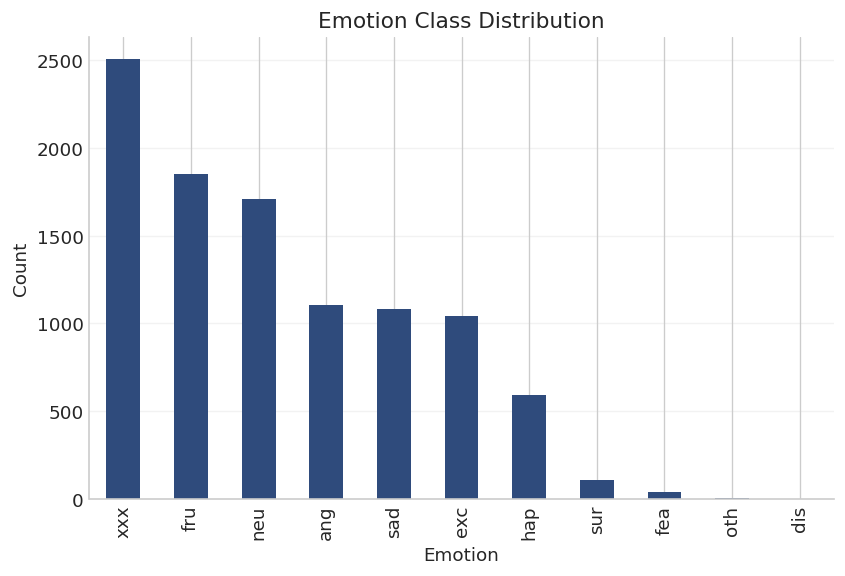

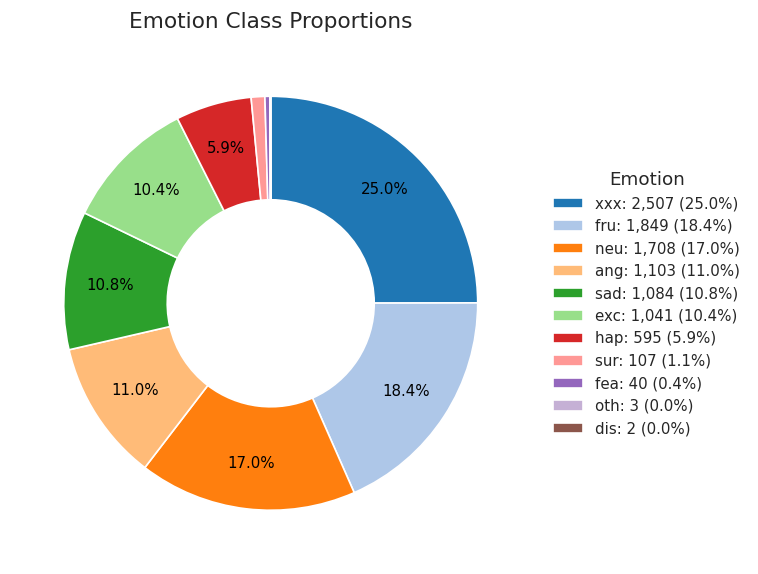

emotion
xxx    2507
fru    1849
neu    1708
ang    1103
sad    1084
exc    1041
hap     595
sur     107
fea      40
oth       3
dis       2
Name: count, dtype: int64

In [41]:
# Emotion distribution (including 'xxx')
emotion_counts = df["emotion"].value_counts()
fig = bar_plot(
    emotion_counts,
    "Emotion Class Distribution",
    "Emotion",
    "Count",
)
plt.show()

fig = pie_plot_thesis(
    emotion_counts,
    "Emotion Class Proportions",
    legend_title="Emotion",
    min_pct_label=4.0,
)
plt.show()

emotion_counts



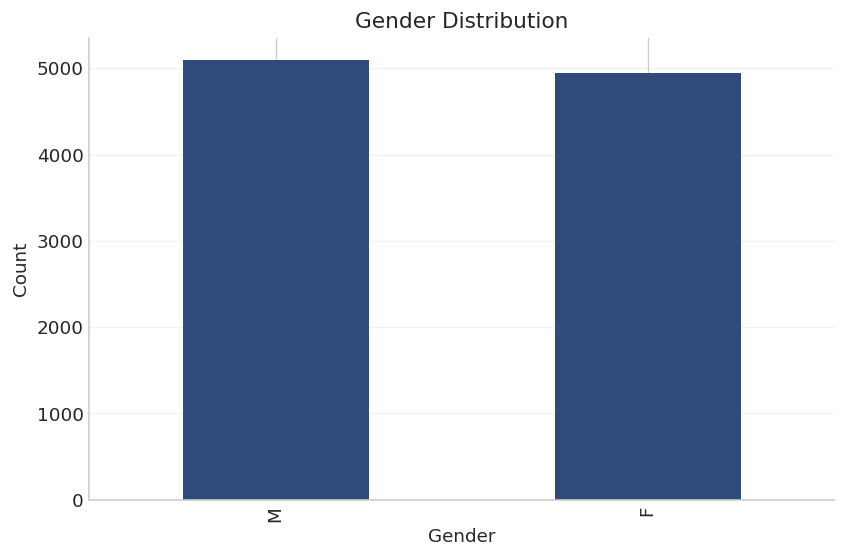

gender
M    5098
F    4941
Name: count, dtype: int64

In [42]:
# Gender distribution
gender_counts = df["gender"].value_counts()
fig = bar_plot(gender_counts, "Gender Distribution", "Gender", "Count")
plt.show()

gender_counts

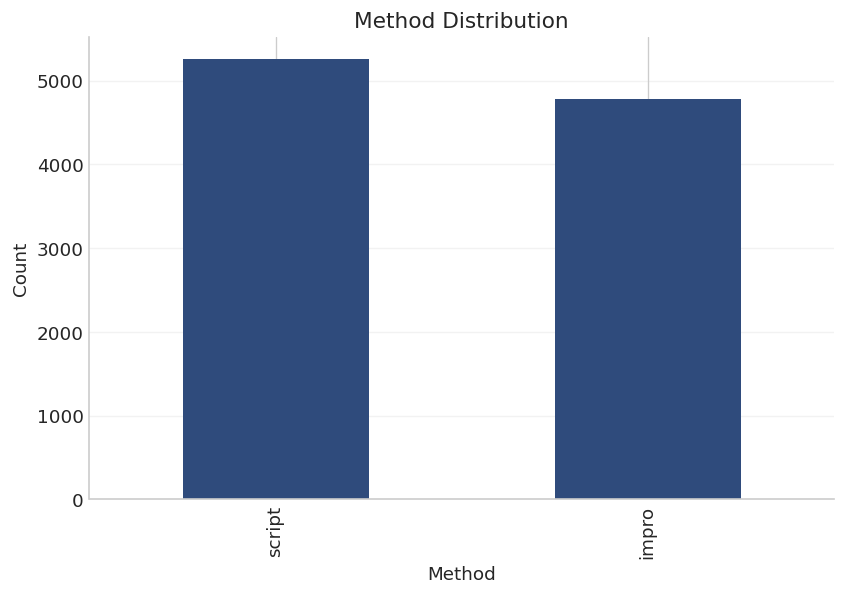

method
script    5255
impro     4784
Name: count, dtype: int64

In [43]:
# Method distribution
method_counts = df["method"].value_counts()
fig = bar_plot(method_counts, "Method Distribution", "Method", "Count")
plt.show()

method_counts

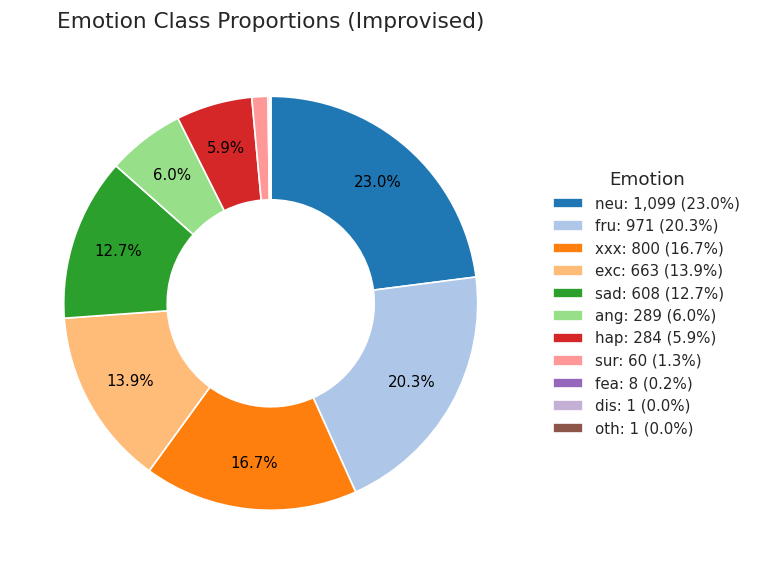

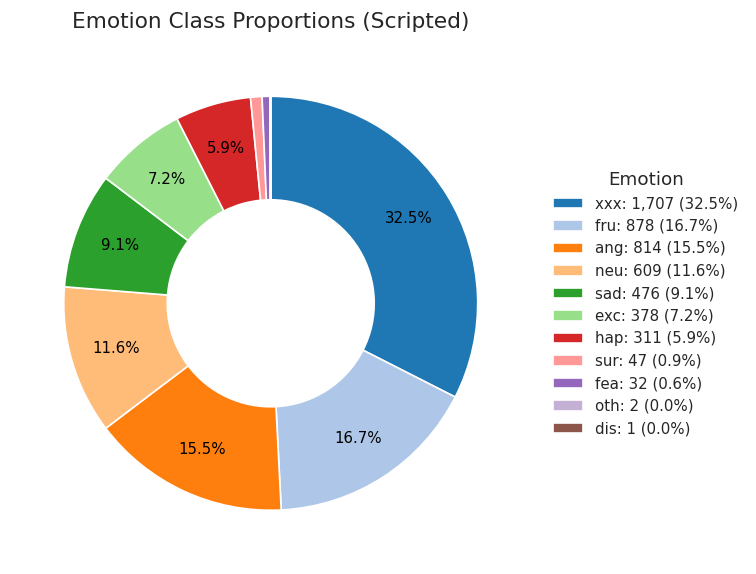

In [44]:
# Emotion class pie charts split by method (improvised vs scripted)
for method_label, title in [("impro", "Improvised"), ("script", "Scripted")]:
    subset = df[df["method"] == method_label]
    counts = subset["emotion"].value_counts()
    fig = pie_plot_thesis(
        counts,
        f"Emotion Class Proportions ({title})",
        legend_title="Emotion",
        min_pct_label=4.0,
    )
    plt.show()



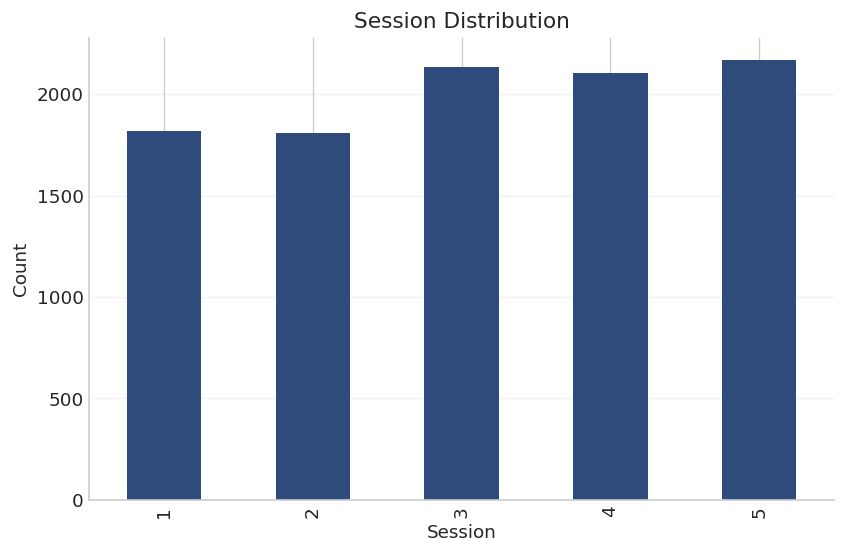

session
1    1819
2    1811
3    2136
4    2103
5    2170
Name: count, dtype: int64

In [45]:
# Session distribution
session_counts = df["session"].value_counts().sort_index()
fig = bar_plot(session_counts, "Session Distribution", "Session", "Count")
plt.show()

session_counts

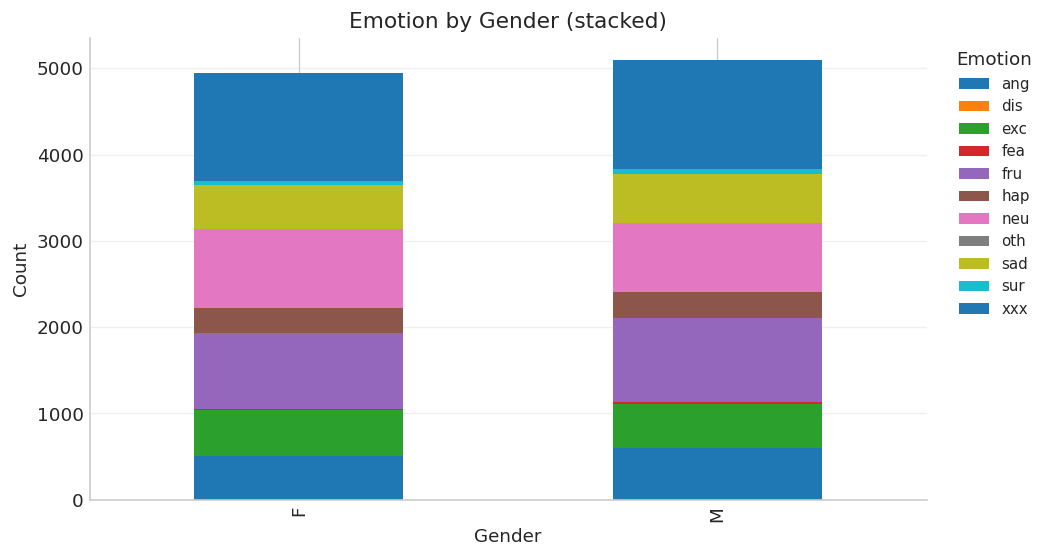

emotion,ang,dis,exc,fea,fru,hap,neu,oth,sad,sur,xxx
gender,,,,,,,,,,,
F,505,1,529,16,883,291,911,2,509,48,1246
M,598,1,512,24,966,304,797,1,575,59,1261


In [46]:
# Emotion by gender (stacked bar)
gender_emotion = pd.crosstab(df["gender"], df["emotion"])
fig, ax = plt.subplots(figsize=(9, 5))
gender_emotion.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Emotion by Gender (stacked)")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.show()

gender_emotion

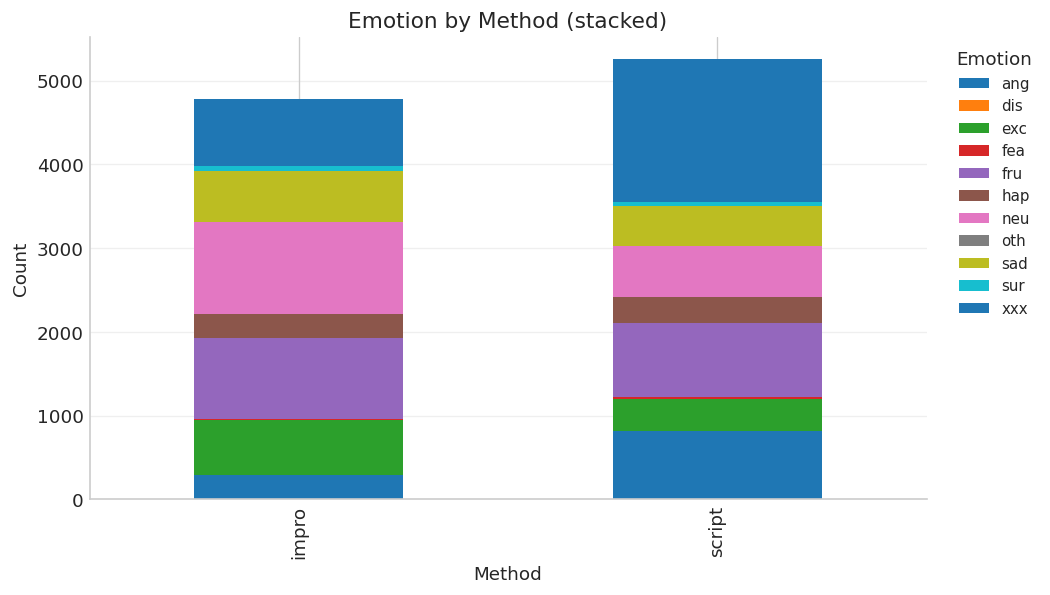

emotion,ang,dis,exc,fea,fru,hap,neu,oth,sad,sur,xxx
method,,,,,,,,,,,
impro,289,1,663,8,971,284,1099,1,608,60,800
script,814,1,378,32,878,311,609,2,476,47,1707


In [47]:
# Emotion by method (stacked bar)
method_emotion = pd.crosstab(df["method"], df["emotion"])
fig, ax = plt.subplots(figsize=(9, 5))
method_emotion.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Emotion by Method (stacked)")
ax.set_xlabel("Method")
ax.set_ylabel("Count")
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.show()

method_emotion

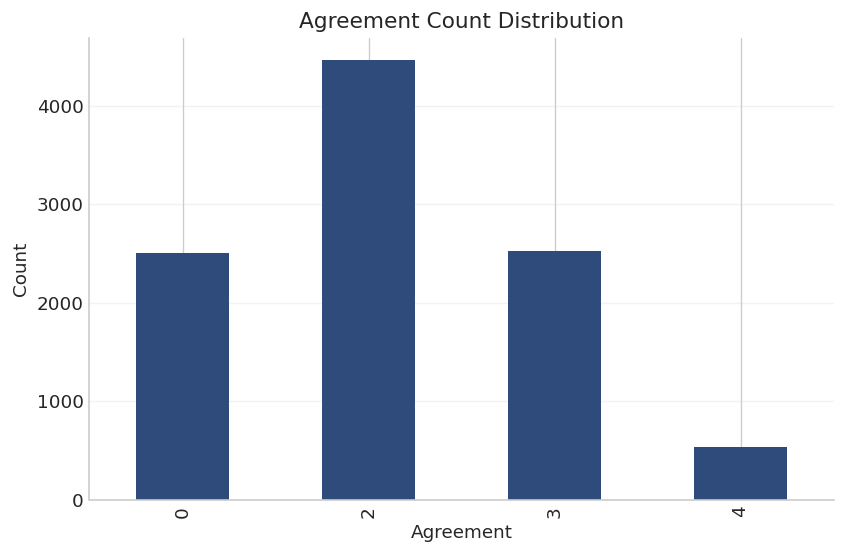

agreement
0    2507
2    4466
3    2526
4     540
Name: count, dtype: int64

In [48]:
# Agreement distribution
agreement_counts = df["agreement"].value_counts().sort_index()
fig = bar_plot(
    agreement_counts,
    "Agreement Count Distribution",
    "Agreement",
    "Count",
)
plt.show()

agreement_counts

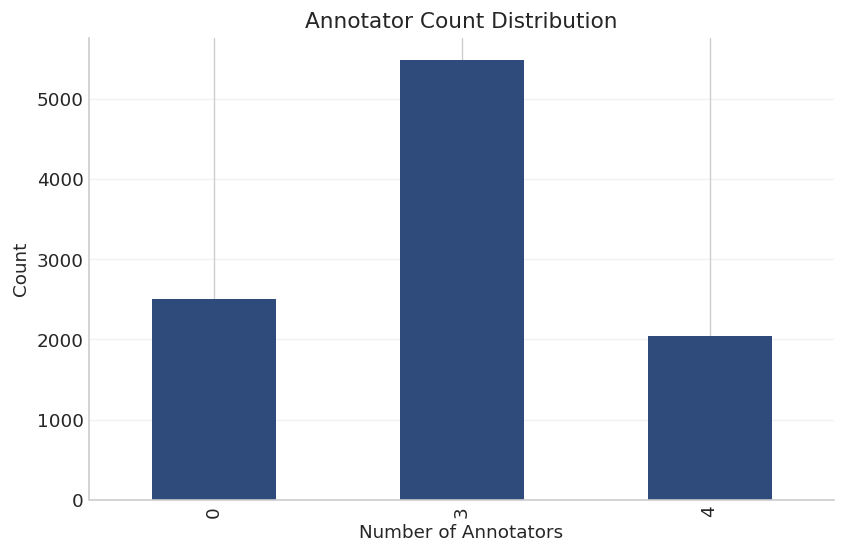

n_annotators
0    2507
3    5490
4    2042
Name: count, dtype: int64

In [49]:
# Annotator count distribution
annotator_counts = df["n_annotators"].value_counts().sort_index()
fig = bar_plot(
    annotator_counts,
    "Annotator Count Distribution",
    "Number of Annotators",
    "Count",
)
plt.show()

annotator_counts

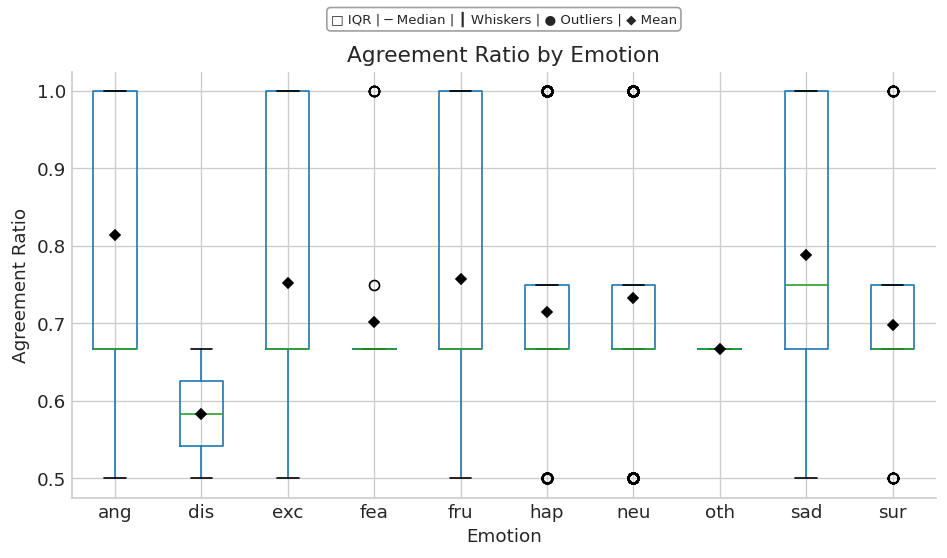

,count,mean,50%,min,max
emotion,,,,,
ang,1103.0,0.814294,0.666667,0.500000,1.000000
dis,2.0,0.583333,0.583333,0.500000,0.666667
exc,1041.0,0.752161,0.666667,0.500000,1.000000
fea,40.0,0.702083,0.666667,0.666667,1.000000
fru,1849.0,0.757211,0.666667,0.500000,1.000000
hap,595.0,0.714706,0.666667,0.500000,1.000000
neu,1708.0,0.732923,0.666667,0.500000,1.000000
oth,3.0,0.666667,0.666667,0.666667,0.666667
sad,1084.0,0.787592,0.750000,0.500000,1.000000


In [50]:
# Agreement ratio by emotion (excluding rows with 0 annotators)
ratio_df = df[df["n_annotators"] > 0].copy()
ratio_df["agreement_ratio"] = ratio_df["agreement"] / ratio_df["n_annotators"]

fig, ax = plt.subplots(figsize=(9, 5))
ratio_df.boxplot(
    column="agreement_ratio",
    by="emotion",
    ax=ax,
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 4},
)
fig.subplots_adjust(top=0.86)
fig.text(
    0.5,
    0.96,
    "□ IQR | ─ Median | ┃ Whiskers | ● Outliers | ◆ Mean",
    ha="center",
    va="top",
    fontsize=8,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="gray"),
)
ax.set_title("Agreement Ratio by Emotion")
ax.set_xlabel("Emotion")
ax.set_ylabel("Agreement Ratio")
fig.suptitle("")
plt.show()

ratio_df.groupby("emotion")["agreement_ratio"].describe()[["count", "mean", "50%", "min", "max"]]

In [51]:
# Session-based train/test split (Session 5 as test)
valid_df = df[(df["emotion"] != "xxx") & (df["agreement"] > 0)].copy()
session_counts = valid_df["session"].value_counts().sort_index()

train_sessions = [1, 2, 3, 4]
test_sessions = [5]

train_count = session_counts.loc[train_sessions].sum()
test_count = session_counts.loc[test_sessions].sum()
total_count = train_count + test_count

pd.DataFrame(
    {
        "count": [train_count, test_count],
        "ratio": [train_count / total_count, test_count / total_count],
    },
    index=["train (sessions 1-4)", "test (session 5)"],
)

,count,ratio
train (sessions 1-4),5882,0.780935
test (session 5),1650,0.219065


In [52]:
# Audio clip duration analysis (based on file paths)
from pathlib import Path
import librosa

audio_root = repo_root / "datasets" / "IEMOCAP"
durations = []
missing = []

for rel_path in df["path"].tolist():
    audio_path = audio_root / rel_path
    if not audio_path.exists():
        missing.append(str(audio_path))
        continue
    try:
        duration = librosa.get_duration(path=audio_path)
        durations.append(duration)
    except Exception:
        continue

durations_series = pd.Series(durations, name="duration_s")
durations_series.describe()

count    10039.000000
mean         4.460078
std          3.064676
min          0.584937
25%          2.330000
50%          3.519938
75%          5.709937
max         34.138750
Name: duration_s, dtype: float64

## Actor-Level Analysis

IEMOCAP actor identity is derived from `session` plus speaker marker in filename (`_F###` / `_M###`).

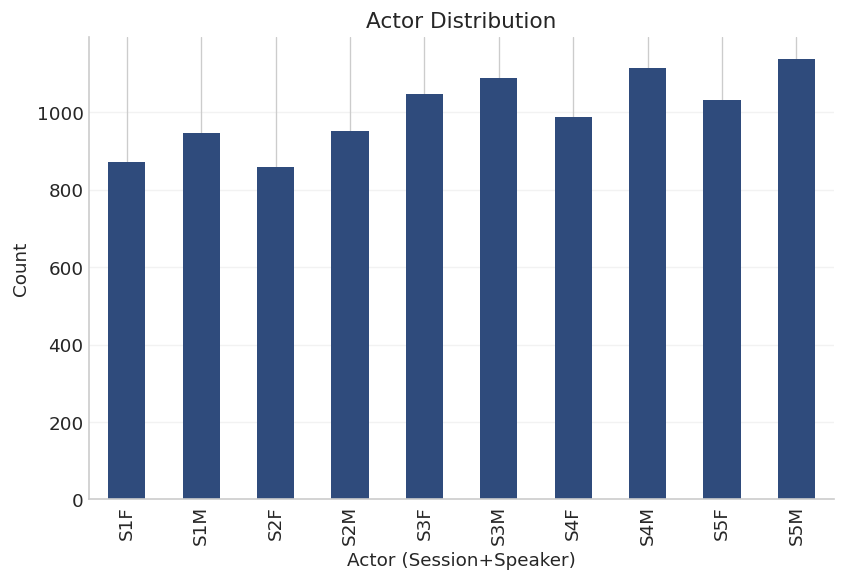

actor_id
S1F     873
S1M     946
S2F     859
S2M     952
S3F    1048
S3M    1088
S4F     987
S4M    1116
S5F    1033
S5M    1137
Name: count, dtype: int64

In [53]:
# Derive speaker token and actor_id from path
df['speaker'] = df['path'].astype(str).str.extract(r'_([FM])\d+\.wav$', expand=False)
df['actor_id'] = 'S' + df['session'].astype(int).astype(str) + df['speaker']

actor_counts = df['actor_id'].value_counts().sort_index()
fig = bar_plot(actor_counts, "Actor Distribution", "Actor (Session+Speaker)", "Count")
plt.show()

actor_counts


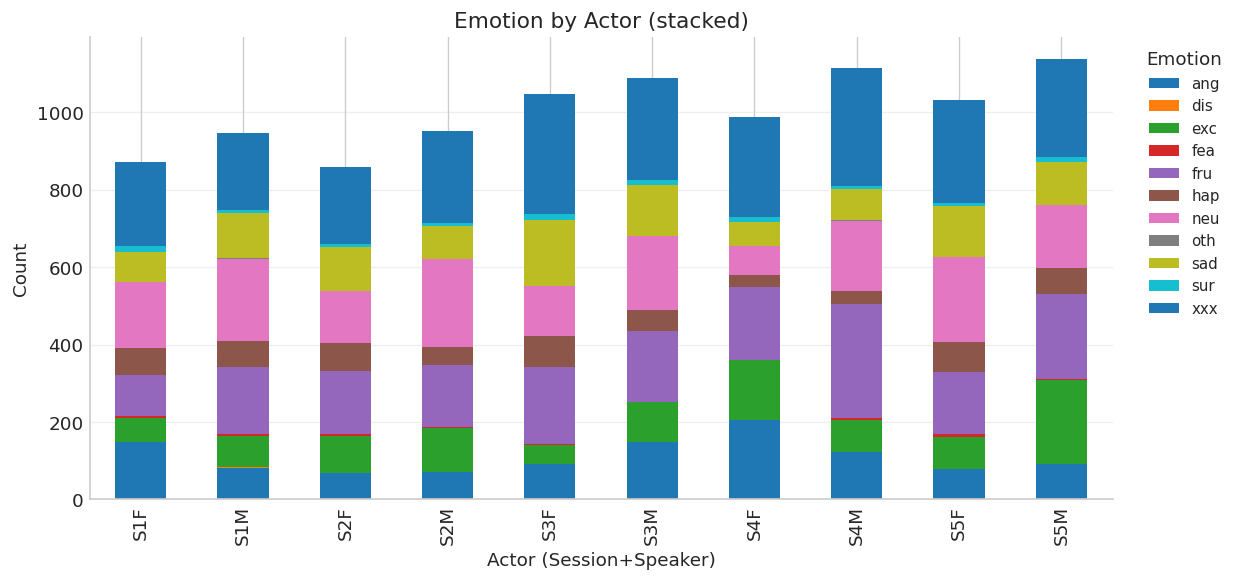

emotion,ang,dis,exc,fea,fru,hap,neu,oth,sad,sur,xxx
actor_id,,,,,,,,,,,
S1F,147,0,63,5,107,69,171,0,78,15,218
S1M,82,1,80,7,173,66,213,1,116,10,197
S2F,67,0,96,5,165,70,135,1,113,8,199
S2M,70,0,114,4,160,47,227,0,84,9,237
S3F,92,0,48,2,199,80,130,0,172,15,310
S3M,148,1,103,0,183,55,190,0,133,13,262
S4F,205,0,154,2,188,31,76,0,62,11,258
S4M,122,0,84,5,293,34,182,1,81,8,306
S5F,78,0,82,8,161,77,221,0,132,7,267


In [54]:
# Actor by emotion (stacked bar)
actor_emotion = pd.crosstab(df['actor_id'], df['emotion'])
fig, ax = plt.subplots(figsize=(11, 5))
actor_emotion.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Emotion by Actor (stacked)")
ax.set_xlabel("Actor (Session+Speaker)")
ax.set_ylabel("Count")
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.show()

actor_emotion


## Conversation Emotion Timeline (Per Speaker)

This section plots emotion progression over transcript time for one conversation, split by speaker.
Set `include_xxx=True` to include uncertain labels (`xxx`).

In [55]:
import re
from matplotlib.lines import Line2D

_PATH_RE = re.compile(r"^(Session\d+)/sentences/wav/([^/]+)/([^/]+)\.wav$")
_TRANSCRIPT_RE = re.compile(r"^(\S+)\s+\[(\d+\.\d+)-(\d+\.\d+)\]:")


def parse_path_fields(path: str) -> tuple[str, str, str, int, int]:
    match = _PATH_RE.match(path)
    if match is None:
        raise ValueError(f"Unexpected audio path format: {path}")

    session_str, conversation_id, utterance_id = match.groups()
    speaker = utterance_id.split("_")[-1][0]
    utt_idx = int(utterance_id[-3:])
    session_num = int(session_str.replace("Session", ""))
    return conversation_id, utterance_id, speaker, utt_idx, session_num


def load_transcript_times(iemocap_root: Path, conversation_id: str, session: int) -> pd.DataFrame:
    transcript_path = iemocap_root / f"Session{session}" / "dialog" / "transcriptions" / f"{conversation_id}.txt"
    if not transcript_path.exists():
        raise FileNotFoundError(f"Transcript not found: {transcript_path}")

    rows = []
    with transcript_path.open("r", encoding="utf-8", errors="ignore") as handle:
        for line in handle:
            line = line.strip()
            match = _TRANSCRIPT_RE.match(line)
            if match is None:
                continue
            utterance_id, start_s, end_s = match.groups()
            rows.append(
                {
                    "utterance_id": utterance_id,
                    "transcript_start_s": float(start_s),
                    "transcript_end_s": float(end_s),
                }
            )

    return pd.DataFrame(rows)


def build_timeline_df(df: pd.DataFrame, iemocap_root: Path, include_xxx: bool = False) -> pd.DataFrame:
    timeline = df.copy()

    parsed = timeline["path"].apply(parse_path_fields)
    timeline[["conversation_id", "utterance_id", "speaker", "utt_idx", "session"]] = pd.DataFrame(
        parsed.tolist(),
        index=timeline.index,
    )

    transcript_frames = []
    for (session, conversation_id) in timeline[["session", "conversation_id"]].drop_duplicates().itertuples(index=False):
        transcript_frames.append(load_transcript_times(iemocap_root, conversation_id, int(session)))

    transcript_df = pd.concat(transcript_frames, ignore_index=True)
    transcript_df = transcript_df.sort_values(["utterance_id", "transcript_start_s", "transcript_end_s"])
    transcript_df = transcript_df.drop_duplicates(subset=["utterance_id"], keep="first")
    timeline = timeline.merge(transcript_df, how="left", on="utterance_id", validate="many_to_one")

    if not include_xxx:
        timeline = timeline[timeline["emotion"] != "xxx"].copy()

    timeline = timeline.sort_values(["conversation_id", "transcript_start_s", "utt_idx"]).reset_index(drop=True)
    return timeline


def plot_conversation_timeline(
    timeline_df: pd.DataFrame,
    conversation_id: str,
    connect_points: bool = True,
) -> plt.Figure:
    convo_df = timeline_df[timeline_df["conversation_id"] == conversation_id].copy()
    if convo_df.empty:
        raise ValueError(f"Conversation not found in timeline data: {conversation_id}")

    if convo_df["transcript_start_s"].isna().any():
        missing_count = int(convo_df["transcript_start_s"].isna().sum())
        raise ValueError(f"Missing transcript timestamp rows for {conversation_id}: {missing_count}")

    base_order = ["neu", "hap", "exc", "sad", "ang", "fru", "fea", "sur", "dis", "oth", "xxx"]
    present = set(convo_df["emotion"].tolist())
    ordered_emotions = [emo for emo in base_order if emo in present]
    extras = sorted(present.difference(ordered_emotions))
    ordered_emotions.extend(extras)

    emo_to_y = {emo: idx for idx, emo in enumerate(ordered_emotions)}
    convo_df["emotion_y"] = convo_df["emotion"].map(emo_to_y)

    color_cycle = plt.cm.get_cmap("tab10", max(len(ordered_emotions), 1))
    emotion_colors = {emo: color_cycle(idx) for idx, emo in enumerate(ordered_emotions)}

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    for ax, speaker in zip(axes, ["F", "M"]):
        speaker_df = convo_df[convo_df["speaker"] == speaker].sort_values(["transcript_start_s", "utt_idx"])

        if speaker_df.empty:
            ax.text(0.5, 0.5, f"No speaker {speaker} utterances", transform=ax.transAxes, ha="center", va="center")
        else:
            if connect_points and len(speaker_df) > 1:
                ax.plot(
                    speaker_df["transcript_start_s"],
                    speaker_df["emotion_y"],
                    color="#9aa0a6",
                    alpha=0.45,
                    linewidth=1.0,
                    zorder=1,
                )

            point_colors = [emotion_colors[e] for e in speaker_df["emotion"]]
            ax.scatter(
                speaker_df["transcript_start_s"],
                speaker_df["emotion_y"],
                c=point_colors,
                s=36,
                edgecolors="black",
                linewidths=0.3,
                zorder=2,
            )

        ax.set_yticks(range(len(ordered_emotions)))
        ax.set_yticklabels(ordered_emotions)
        ax.set_ylabel(f"Speaker {speaker}")
        ax.grid(axis="x", alpha=0.2)
        ax.grid(axis="y", alpha=0.15)

    session_value = int(convo_df["session"].iloc[0])
    method_value = convo_df["method"].mode().iloc[0]
    fig.suptitle(
        f"Emotion Timeline by Speaker: {conversation_id} (Session {session_value}, method={method_value})",
        y=0.98,
    )
    axes[-1].set_xlabel("Transcript time (seconds)")

    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=emotion_colors[e], markeredgecolor="black", markersize=7, label=e)
        for e in ordered_emotions
    ]
    fig.legend(handles=legend_handles, title="Emotion", loc="upper right", bbox_to_anchor=(0.99, 0.99))
    fig.tight_layout(rect=[0, 0, 0.93, 0.95])
    return fig


In [56]:
# Controls
selected_conversation = "Ses01M_script02_2"
include_xxx = False
connect_points = True

iemocap_root = repo_root / "datasets" / "IEMOCAP"
timeline_df = build_timeline_df(df, iemocap_root, include_xxx=include_xxx)

coverage = timeline_df["transcript_start_s"].notna().mean() * 100
print(f"Timeline rows: {len(timeline_df):,} | timestamp coverage: {coverage:.2f}% | include_xxx={include_xxx}")
print(f"Available conversations: {timeline_df['conversation_id'].nunique()}")


Timeline rows: 7,532 | timestamp coverage: 100.00% | include_xxx=False
Available conversations: 151


/tmp/ipykernel_576130/4239894348.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_cycle = plt.cm.get_cmap("tab10", max(len(ordered_emotions), 1))


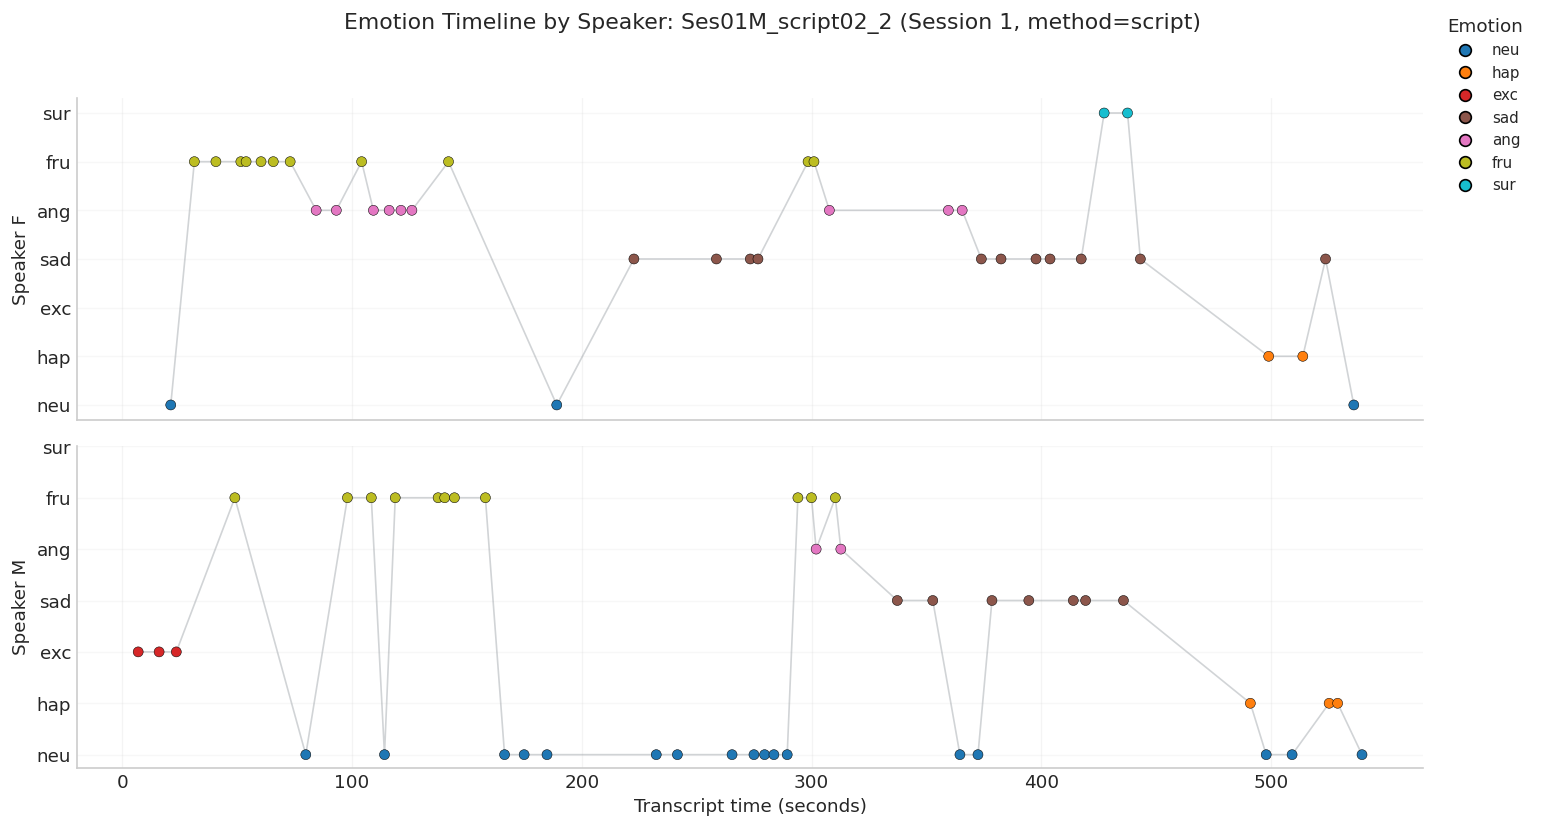

In [57]:
fig = plot_conversation_timeline(
    timeline_df=timeline_df,
    conversation_id=selected_conversation,
    connect_points=connect_points,
)
plt.show()


## Emotion Transition Analysis

Estimate transition probabilities `P(next_emotion | current_emotion)` from utterance sequences.
You can compute transitions either within the same speaker stream or across full conversation turn order.


In [ ]:
def build_transition_table(
    timeline_df: pd.DataFrame,
    mode: str = "same_speaker",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Returns (pair_df, counts, probs) where rows are current emotion and columns are next emotion.
    mode="same_speaker": transitions within each (conversation_id, speaker) sequence.
    mode="conversation_turn": transitions across full conversation turn order (speaker-agnostic).
    """
    valid_modes = {"same_speaker", "conversation_turn"}
    if mode not in valid_modes:
        raise ValueError(f"mode must be one of {valid_modes}, got {mode}")

    work = timeline_df.copy()
    work = work.dropna(subset=["transcript_start_s"]).copy()

    if mode == "same_speaker":
        group_cols = ["conversation_id", "speaker"]
        work = work.sort_values(group_cols + ["transcript_start_s", "utt_idx"]).copy()
    else:
        group_cols = ["conversation_id"]
        work = work.sort_values(group_cols + ["transcript_start_s", "utt_idx"]).copy()

    work["next_emotion"] = work.groupby(group_cols)["emotion"].shift(-1)
    pairs = work.dropna(subset=["next_emotion"])[["emotion", "next_emotion"]].copy()

    counts = pd.crosstab(pairs["emotion"], pairs["next_emotion"])
    probs = counts.div(counts.sum(axis=1).replace(0, pd.NA), axis=0).fillna(0.0)
    return pairs, counts, probs


def plot_transition_heatmap(matrix: pd.DataFrame, title: str, cmap: str = "Blues", fmt: str = "{:.2f}") -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(matrix.values, aspect="auto", cmap=cmap)

    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Next emotion")
    ax.set_ylabel("Current emotion")
    ax.set_title(title)

    ax.grid(False)

    threshold = matrix.values.max() * 0.6 if matrix.size else 0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iat[i, j]
            text_color = "white" if value >= threshold and value > 0 else "black"
            ax.text(j, i, fmt.format(value), ha="center", va="center", fontsize=8, color=text_color)

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Probability" if "Prob" in title else "Count", rotation=90)
    fig.tight_layout()
    return fig


In [59]:
# Controls
transition_include_xxx = False
# "same_speaker" or "conversation_turn"
transition_mode = "same_speaker"

transition_timeline_df = build_timeline_df(df, iemocap_root, include_xxx=transition_include_xxx)
pairs_df, transition_counts, transition_probs = build_transition_table(
    transition_timeline_df,
    mode=transition_mode,
)

print(f"Transitions analyzed: {len(pairs_df):,}")
print(f"Mode: {transition_mode} | include_xxx={transition_include_xxx}")
display(transition_counts)
display((transition_probs * 100).round(2))


Transitions analyzed: 7,230
Mode: same_speaker | include_xxx=False


next_emotion,ang,dis,exc,fea,fru,hap,neu,oth,sad,sur
emotion,,,,,,,,,,
ang,733,0,3,0,232,1,50,0,27,3
dis,0,0,0,0,1,1,0,0,0,0
exc,1,0,789,3,26,94,73,0,9,15
fea,0,0,8,21,1,5,3,0,2,0
fru,265,0,21,1,1194,3,216,0,80,16
hap,0,1,77,0,4,371,43,1,29,10
neu,61,1,67,1,257,50,1139,1,46,25
oth,1,0,0,0,1,0,0,0,0,0
sad,15,0,7,3,77,39,50,0,837,12


next_emotion,ang,dis,exc,fea,fru,hap,neu,oth,sad,sur
emotion,,,,,,,,,,
ang,69.88,0.00,0.29,0.00,22.12,0.10,4.77,0.00,2.57,0.29
dis,0.00,0.00,0.00,0.00,50.00,50.00,0.00,0.00,0.00,0.00
exc,0.10,0.00,78.12,0.30,2.57,9.31,7.23,0.00,0.89,1.49
fea,0.00,0.00,20.00,52.50,2.50,12.50,7.50,0.00,5.00,0.00
fru,14.76,0.00,1.17,0.06,66.48,0.17,12.03,0.00,4.45,0.89
hap,0.00,0.19,14.37,0.00,0.75,69.22,8.02,0.19,5.41,1.87
neu,3.70,0.06,4.07,0.06,15.59,3.03,69.11,0.06,2.79,1.52
oth,50.00,0.00,0.00,0.00,50.00,0.00,0.00,0.00,0.00,0.00
sad,1.44,0.00,0.67,0.29,7.40,3.75,4.81,0.00,80.48,1.15


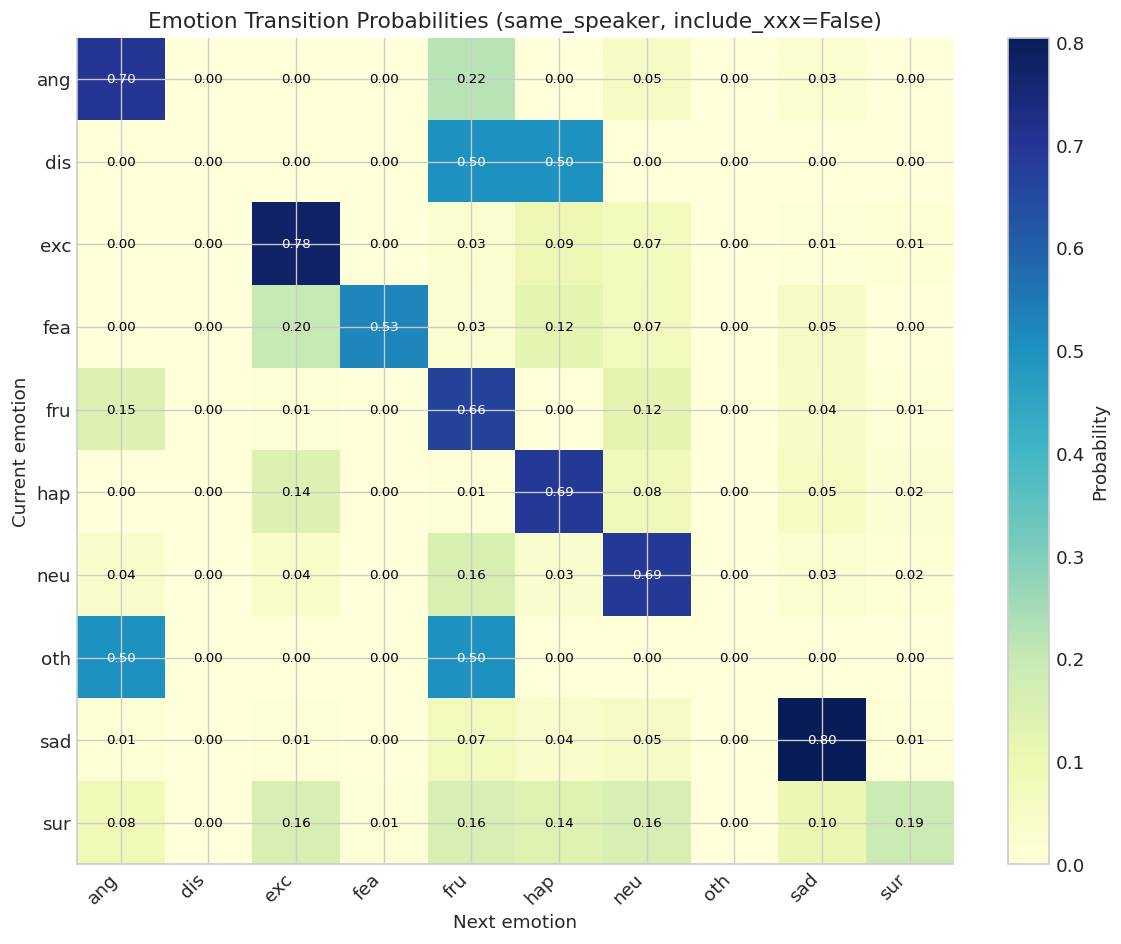

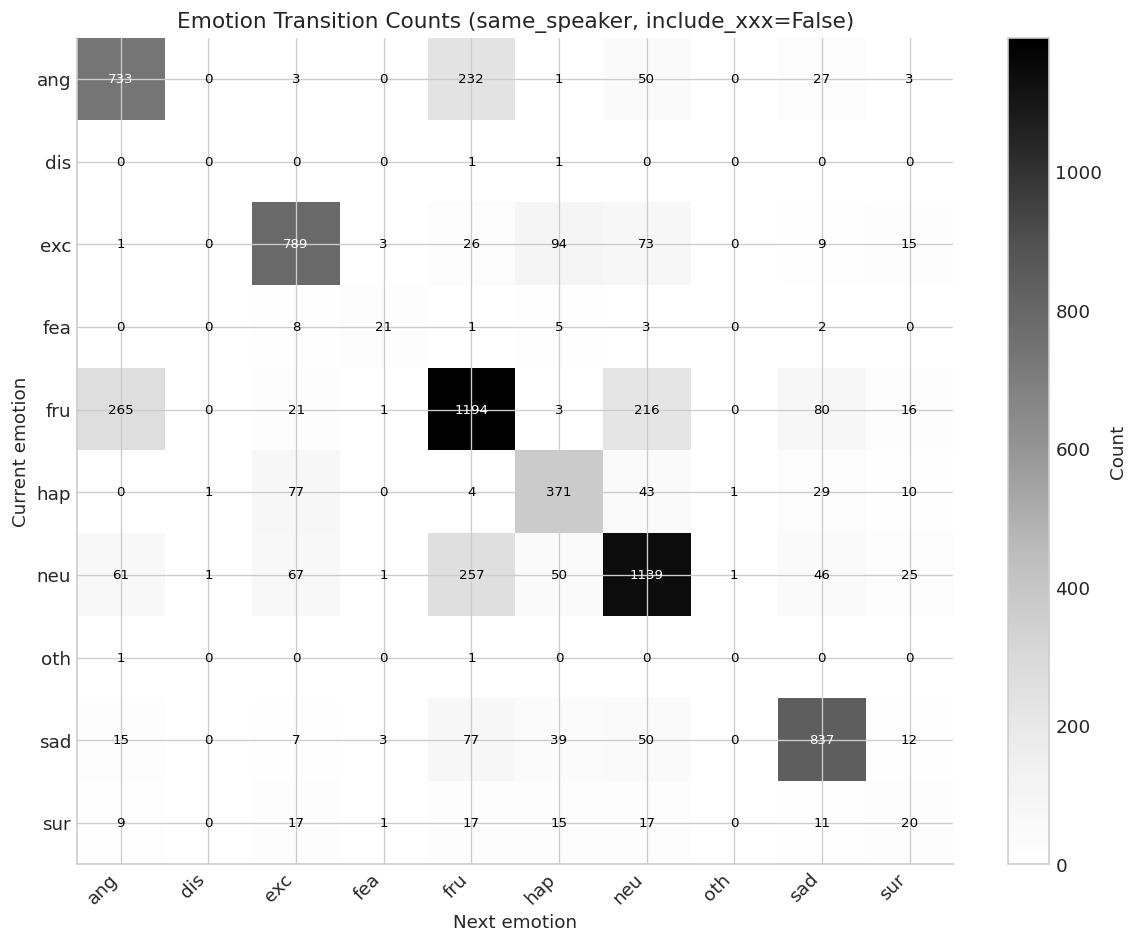

In [61]:
fig = plot_transition_heatmap(
    transition_probs,
    title=f"Emotion Transition Probabilities ({transition_mode}, include_xxx={transition_include_xxx})",
    cmap="YlGnBu",
    fmt="{:.2f}",
)
plt.show()

fig = plot_transition_heatmap(
    transition_counts,
    title=f"Emotion Transition Counts ({transition_mode}, include_xxx={transition_include_xxx})",
    cmap="Greys",
    fmt="{:.0f}",
)
plt.show()
